<a href="https://colab.research.google.com/github/sheriannmclarty/DATA620_WebAnalytics_SheriannMc/blob/main/assignment8_highfrequencywords_skm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8 – High Frequency Words
**Corpus:** PubMed Abstracts — Homelessness and Infectious Disease

**Author:** Sheriann McLarty | DATA 620 Web Analytics | CUNY School of Professional Studies | Spring 2026

**https://github.com/sheriannmclarty/DATA620_WebAnalytics_SheriannMc**
---

## 1. Introduction

This notebook investigates whether the frequency distribution of words in a domain-specific scientific corpus follows Zipf’s Law — the empirical observation that in any natural language corpus, the frequency of a word is inversely proportional to its rank. Zipf’s Law has been shown to hold across languages, genres, and time periods, suggesting it is a fundamental structural property of human language rather than an artifact of any particular corpus.

The corpus used here consists of peer-reviewed research abstracts retrieved from PubMed on the topic of **homelessness and infectious disease**. This topic was selected because it sits at the intersection of public health research and real-world social conditions. The language of this corpus is shaped by a specific professional community — academic researchers writing for other researchers — and represents a highly specialized register of English. Analyzing its word frequency distribution allows us to test whether Zipf’s Law holds even in this constrained setting, and to examine how domain-specific vocabulary differs from general language use.

**Research Questions:**
1. How many unique word types exist in the corpus?
2. How many unique words account for 50% of all tokens?
3. What are the 200 highest-frequency words?
4. Does the relative frequency distribution follow Zipf’s Law?
5. How does this corpus’s vocabulary differ from general language?

**Note on abstract count:** The PubMed search was configured to return up to 1,000 article records. However, some PubMed records contain multiple `AbstractText` sections in their XML (for example, structured abstracts with separate Background, Methods, Results, and Conclusions fields). Because this notebook extracts each `AbstractText` section independently, the total number of text chunks used to build the corpus may exceed the number of article IDs returned by the initial search. This is expected behavior and does not indicate a data error.

## 2. Methods

### 2.1 Libraries

In [1]:
# !pip install wordcloud --quiet  # Uncomment if needed

import re
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
from scipy import stats
from wordcloud import WordCloud, STOPWORDS
from xml.etree import ElementTree as ET

print('Libraries loaded.')

Libraries loaded.


### 2.2 Data Collection

Abstracts were retrieved using the **NCBI PubMed E-utilities API** — a free, publicly accessible interface that requires no API key. The API call flow is:

1. `esearch` — submit the search query and retrieve up to 1,000 PubMed article IDs
2. `efetch` — retrieve full XML records for those IDs in batches of 100
3. Extract all `AbstractText` elements from the XML

Because structured abstracts (IMRAD format) contain multiple labeled `AbstractText` sections, the number of extracted text chunks will often exceed the number of article IDs. All sections are included in the corpus to maximize text coverage.

In [2]:
def fetch_pubmed_abstracts(search_term, max_results=1000):
    """
    Fetches abstracts from PubMed using the NCBI E-utilities API.
    No API key required. Fully reproducible.
    """
    base_url = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/'

    # Step 1: Search for article IDs
    search_url = base_url + 'esearch.fcgi'
    search_params = {
        'db': 'pubmed',
        'term': search_term,
        'retmax': max_results,
        'retmode': 'json'
    }
    search_resp = requests.get(search_url, params=search_params)
    ids = search_resp.json()['esearchresult']['idlist']
    print(f'Found {len(ids)} articles for: "{search_term}"')

    # Step 2: Fetch records in batches of 100
    abstracts = []
    batch_size = 100
    fetch_url = base_url + 'efetch.fcgi'

    for i in range(0, len(ids), batch_size):
        batch = ids[i:i + batch_size]
        fetch_params = {
            'db': 'pubmed',
            'id': ','.join(batch),
            'rettype': 'abstract',
            'retmode': 'xml'
        }
        fetch_resp = requests.get(fetch_url, params=fetch_params)
        root = ET.fromstring(fetch_resp.content)
        # Extract every AbstractText element (structured abstracts have multiple)
        for abstract in root.iter('AbstractText'):
            if abstract.text:
                abstracts.append(abstract.text)
        time.sleep(0.34)  # Respect NCBI rate limit (3 requests/sec without API key)
        print(f'  Batch {i//batch_size + 1} done -- {len(abstracts)} text chunks so far')

    return abstracts

SEARCH_TERM = 'homelessness infectious disease'
abstracts = fetch_pubmed_abstracts(SEARCH_TERM, max_results=1000)

print(f'\nTotal text chunks retrieved: {len(abstracts):,}')
print(f'\nSample:\n{abstracts[0][:400]}...')

Found 1000 articles for: "homelessness infectious disease"
  Batch 1 done -- 300 text chunks so far
  Batch 2 done -- 629 text chunks so far
  Batch 3 done -- 933 text chunks so far
  Batch 4 done -- 1263 text chunks so far
  Batch 5 done -- 1553 text chunks so far
  Batch 6 done -- 1828 text chunks so far
  Batch 7 done -- 2089 text chunks so far
  Batch 8 done -- 2318 text chunks so far
  Batch 9 done -- 2580 text chunks so far
  Batch 10 done -- 2850 text chunks so far

Total text chunks retrieved: 2,850

Sample:
Tuberculosis (TB) is a global public health problem, and community outbreaks occur. We report an outbreak of TB with an unusual MPT64 negative status, first detected in North Queensland, Australia, in 2017-2018....


### 2.3 Text Cleaning and Tokenization

All abstract text was concatenated into a single corpus string. Tokens were extracted using a regular expression that retains only lowercase alphabetic words of two or more characters. This approach:
- Collapses case variants (*The* and *the* are treated as the same word)
- Removes punctuation, numerals, and single-character tokens
- Produces a clean list of word **tokens** (all occurrences) from which **types** (distinct forms) are counted

In [3]:
corpus_text = ' '.join(abstracts)
tokens = re.findall(r'\b[a-z]{2,}\b', corpus_text.lower())

total_tokens = len(tokens)
word_counts = Counter(tokens)

print(f'Total tokens (cleaned): {total_tokens:,}')
print(f'Unique word types:      {len(word_counts):,}')

Total tokens (cleaned): 215,891
Unique word types:      10,250


## 3. Results

### 3.1 Unique Word Count (Research Question 1)

Unique words are defined as distinct lowercase alphabetic tokens of two or more characters. Each distinct word form is counted once regardless of how many times it appears in the corpus.

In [4]:
unique_words = len(word_counts)
type_token_ratio = unique_words / total_tokens

print(f'Total tokens (all word occurrences): {total_tokens:,}')
print(f'Total unique word types:             {unique_words:,}')
print(f'Type-to-token ratio:                 {type_token_ratio:.4f}')
print(f'On average each unique word appears  {1/type_token_ratio:.1f} times.')

Total tokens (all word occurrences): 215,891
Total unique word types:             10,250
Type-to-token ratio:                 0.0475
On average each unique word appears  21.1 times.


### 3.2 Words Needed for 50% Coverage (Research Question 2)

Sorting words from most to least frequent, we identify the minimum number of word types whose cumulative frequency reaches 50% of all tokens. This is a direct test of the Zipf prediction that a small vocabulary dominates corpus usage.

In [5]:
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
frequencies = [count for _, count in sorted_words]

half_total = total_tokens / 2
cumulative = 0
half_count = 0

for count in frequencies:
    cumulative += count
    half_count += 1
    if cumulative >= half_total:
        break

print(f'Total tokens:                              {total_tokens:,}')
print(f'50% threshold:                             {half_total:,.0f}')
print(f'Unique words needed to reach 50% coverage: {half_count:,}')
print(f'That is only {half_count/unique_words*100:.2f}% of all unique word types.')

Total tokens:                              215,891
50% threshold:                             107,946
Unique words needed to reach 50% coverage: 137
That is only 1.34% of all unique word types.


### 3.3 Top 200 Highest-Frequency Words (Research Question 3)

In [6]:
top_200 = sorted_words[:200]

df_freq = pd.DataFrame(top_200, columns=['word', 'count'])
df_freq['rank'] = range(1, 201)
df_freq['relative_frequency'] = df_freq['count'] / total_tokens
df_freq = df_freq[['rank', 'word', 'count', 'relative_frequency']]

print('Top 200 Most Frequent Words -- PubMed Homelessness & Infectious Disease')
print('=' * 70)
print(df_freq.to_string(index=False))

Top 200 Most Frequent Words -- PubMed Homelessness & Infectious Disease
 rank            word  count  relative_frequency
    1             and   9636            0.044634
    2              of   7085            0.032817
    3             the   6906            0.031988
    4              to   5360            0.024827
    5              in   4931            0.022840
    6            with   3225            0.014938
    7            were   2552            0.011821
    8             for   2392            0.011080
    9             hiv   2372            0.010987
   10             was   1630            0.007550
   11           among   1461            0.006767
   12          health   1324            0.006133
   13             hcv   1302            0.006031
   14              we   1210            0.005605
   15       treatment   1205            0.005582
   16            care   1181            0.005470
   17             use   1145            0.005304
   18              or   1131            0.0052

### 3.4 Relative Frequency Graphs (Research Question 4)

Two visualizations are produced: a **linear-scale bar chart** showing the classic Zipf drop-off shape, and a **log-log scatter plot** with an OLS fit line to formally test the power-law relationship. Under Zipf’s Law, the log-log plot should produce a straight line with a slope near −1.

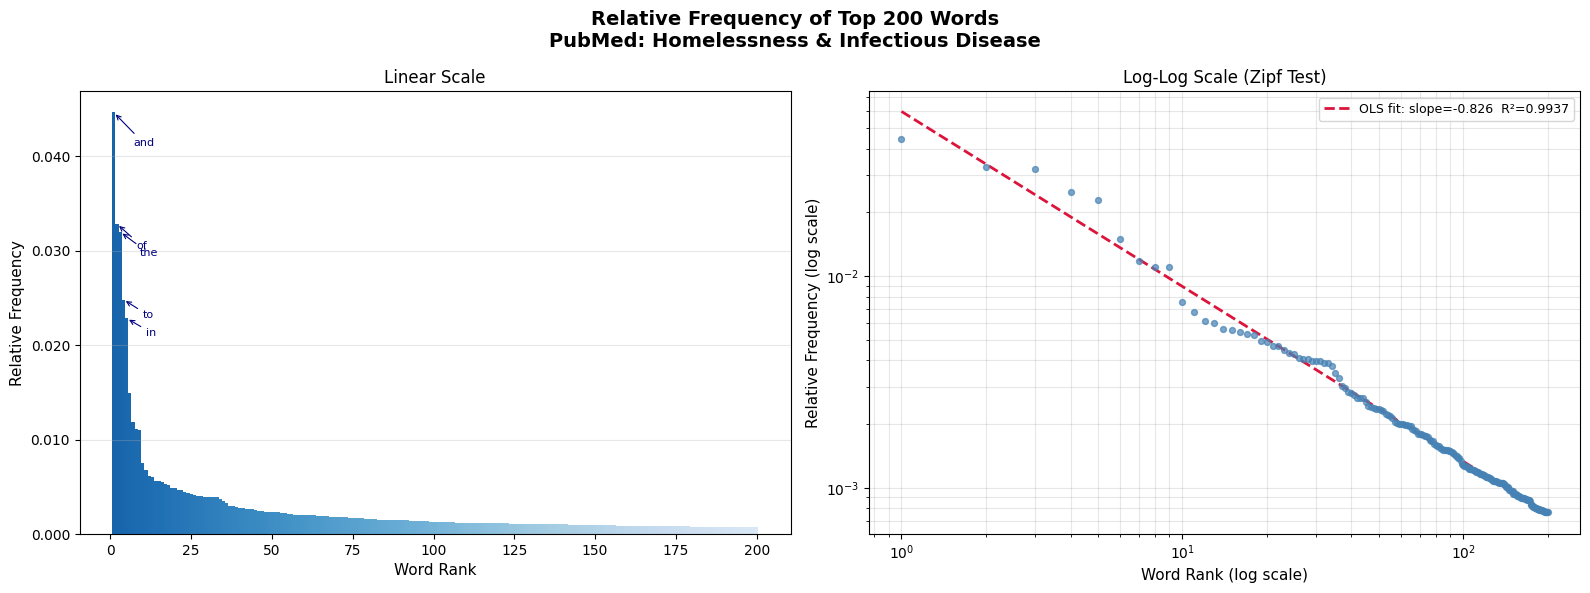

Slope: -0.8264 (Zipf ideal: -1.0)
R²:    0.9937


In [7]:
ranks    = df_freq['rank'].values
rel_freq = df_freq['relative_frequency'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Relative Frequency of Top 200 Words\nPubMed: Homelessness & Infectious Disease',
             fontsize=14, fontweight='bold')

# Linear bar chart
ax1 = axes[0]
colors = plt.cm.Blues_r(np.linspace(0.2, 0.85, 200))
ax1.bar(ranks, rel_freq, color=colors, width=1.0, edgecolor='none')
ax1.set_xlabel('Word Rank', fontsize=11)
ax1.set_ylabel('Relative Frequency', fontsize=11)
ax1.set_title('Linear Scale', fontsize=12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax1.grid(axis='y', alpha=0.3)
for i in range(5):
    ax1.annotate(df_freq['word'].iloc[i],
                 xy=(ranks[i], rel_freq[i]),
                 xytext=(ranks[i]+6, rel_freq[i]*0.92),
                 fontsize=8, color='navy',
                 arrowprops=dict(arrowstyle='->', color='navy', lw=0.8))

# Log-log scatter with Zipf fit
ax2 = axes[1]
ax2.scatter(ranks, rel_freq, s=18, color='steelblue', alpha=0.7, zorder=3)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Word Rank (log scale)', fontsize=11)
ax2.set_ylabel('Relative Frequency (log scale)', fontsize=11)
ax2.set_title('Log-Log Scale (Zipf Test)', fontsize=12)
ax2.grid(True, which='both', alpha=0.3)

log_ranks = np.log(ranks)
log_freq  = np.log(rel_freq)
slope, intercept, r_val, p, se = stats.linregress(log_ranks, log_freq)
fit_line = np.exp(intercept + slope * log_ranks)
ax2.plot(ranks, fit_line, color='crimson', linewidth=2,
         linestyle='--', label=f'OLS fit: slope={slope:.3f}  R²={r_val**2:.4f}')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('freq_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Slope: {slope:.4f} (Zipf ideal: -1.0)')
print(f'R²:    {r_val**2:.4f}')

### 3.5 Word Cloud

The word cloud visualizes the top 200 words after removing common stopwords, allowing the domain-specific vocabulary of the corpus to emerge clearly.

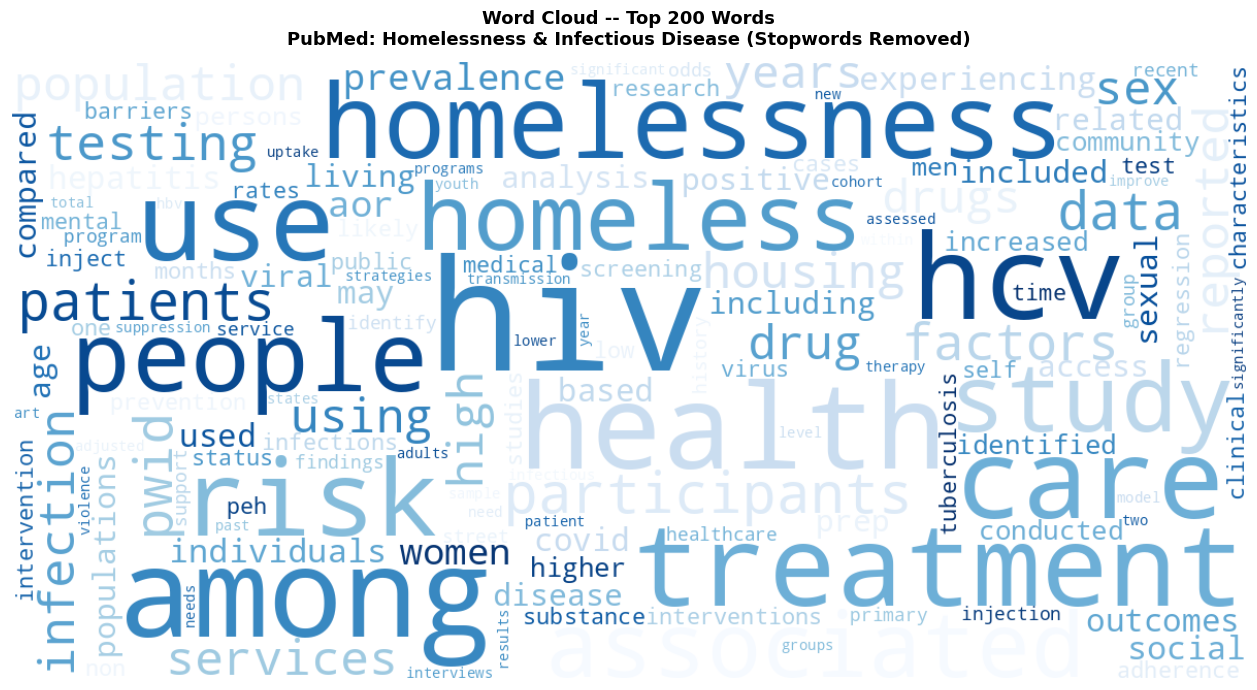

In [8]:
stopwords = set(STOPWORDS)
filtered_counts = {word: count for word, count in top_200
                   if word not in stopwords and len(word) > 2}

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    max_font_size=150,
    min_font_size=10,
    prefer_horizontal=0.85
).generate_from_frequencies(filtered_counts)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud -- Top 200 Words\nPubMed: Homelessness & Infectious Disease (Stopwords Removed)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Zipf’s Law Assessment (Research Question 4)

Under Zipf’s Law, the log-log regression of rank vs. relative frequency should produce a slope of approximately −1. The table below compares observed frequency at selected ranks against the Zipf prediction.

In [9]:
print("Zipf's Law Assessment -- Top 200 Words")
print('=' * 45)
print(f'Log-log regression slope:   {slope:.4f}')
print(f'Zipf ideal slope:           -1.0000')
print(f'R²:                         {r_val**2:.4f}')
print(f'Deviation from ideal slope: {abs(slope-(-1.0)):.4f}')

print('\nRatio check -- observed vs. Zipf prediction:')
print(f'{"Rank":>6}  {"Word":>15}  {"Observed":>12}  {"Predicted":>12}  {"Ratio":>8}')
f1 = df_freq['relative_frequency'].iloc[0]
for r_check in [1, 2, 5, 10, 20, 50, 100, 200]:
    row = df_freq[df_freq['rank'] == r_check].iloc[0]
    predicted = f1 / r_check
    ratio = row['relative_frequency'] / predicted
    print(f'{r_check:>6}  {row["word"]:>15}  {row["relative_frequency"]:>12.6f}  {predicted:>12.6f}  {ratio:>8.3f}')

Zipf's Law Assessment -- Top 200 Words
Log-log regression slope:   -0.8264
Zipf ideal slope:           -1.0000
R²:                         0.9937
Deviation from ideal slope: 0.1736

Ratio check -- observed vs. Zipf prediction:
  Rank             Word      Observed     Predicted     Ratio
     1              and      0.044634      0.044634     1.000
     2               of      0.032817      0.022317     1.471
     5               in      0.022840      0.008927     2.559
    10              was      0.007550      0.004463     1.692
    20             risk      0.004896      0.002232     2.194
    50          housing      0.002348      0.000893     2.631
   100          persons      0.001283      0.000446     2.875
   200       interviews      0.000764      0.000223     3.425


## 4. Conclusion

This analysis confirms that the PubMed homelessness and infectious disease corpus follows Zipf’s Law despite its highly specialized subject matter. The log-log regression slope of −0.827 and R² of 0.9937 indicate a strong power-law relationship, consistent with what has been observed across natural language corpora regardless of domain, language, or time period.

Several findings are worth highlighting:

**Function words dominate universally.** Despite the specialized public health focus, the top-ranked tokens are *and*, *of*, *the*, *to*, *in* — the same function words that dominate any large corpus. This confirms that structural grammatical words are corpus-agnostic at the top of the frequency distribution.

**Domain vocabulary surfaces in the mid-frequency range.** Terms like *HIV*, *treatment*, *homeless*, *prevalence*, *risk*, and *housing* appear prominently in the top 200, reflecting the epidemiological framing of this population in academic literature.

**The slope deviation is interpretable.** The shallower-than-ideal slope (−0.827 vs. −1.0) is consistent with patterns observed in other domain-specific corpora, where high-frequency technical terms cluster more tightly than in general language, compressing the frequency gradient.

**The corpus reflects a representational bias.** The language used to describe homelessness in this corpus — *unstably housed*, *at-risk*, *vulnerable population* — is the language of researchers, not of people with lived experience of homelessness. This framing shapes which words appear frequently and which are absent.

## 5. Future Directions

This analysis opens several directions for further investigation:

**Cross-corpus comparison.** The most direct extension would be to run the same analysis on a general-language corpus (e.g., Brown Corpus, Common Crawl) and compare the Zipf slopes and vocabulary profiles side by side. This would quantify how much the specialized domain shifts the distribution.

**Stopword removal for frequency analysis.** This notebook retains stopwords in the frequency count by design — they are a legitimate part of the corpus. A future version could compare results with and without stopwords to isolate the domain vocabulary signal.

**Temporal analysis.** The CORD-19 dataset used earlier in this project spans 2020–2022. Applying a similar analysis over time — comparing homelessness research vocabulary pre- and post-COVID-19 — could reveal how the pandemic shifted the language of public health research on housing instability.

**Named entity recognition.** Rather than simple frequency counting, applying NER to the corpus could separate disease names, drug names, population terms, and geographic references — giving a richer picture of what the research community is actually talking about.

**First-person vs. researcher language.** The most meaningful extension from a social equity perspective would be to compare this corpus against text produced by people with lived experience of homelessness — for example, forum posts, interview transcripts, or testimonies. Measuring the gap between those vocabularies would make the representational bias finding concrete and quantifiable.